# Population binary decoder: white / grey

**Do 19 neurons jointly distinguish a white bar (lum=1) from grey/no bar (lum=0.5)?**

Session **m19 / 260827 / 10, Probe A**. The units come from session 2's RF list;
unit 436 is explicitly excluded because it has no session-10 spikes.
One sample is one complete **30-trial, approximately 3-second phase**.
The threshold is now **population spike count > 10**, retaining all 400 phases here.
A silent individual unit contributes actual zero event counts.

Compare population **FR**, **pattern**, and **FR + pattern** with the same fixed LDA.
The main model is FR + pattern, chosen before evaluation. Local intervals retain timing
structure without using bar position, trial number, absolute time or phase-onset latency.

Run All on **hhw9l84**, kernel **Python (rfmapping)**. No imputation or substitute model.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from numba import njit
from scipy.io import loadmat
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

session_dir = Path("/mnt/senzailab/Kai/#Recording/m19/260827/260827_10")
rf_units_path = session_dir.parent / "260827_2/data/units_with_rf.npy"
probe = "A"
excluded_unit_ids = [436]  # Explicit known absence, not a decoder-dependent selection.
min_population_spikes = 10  # Strictly greater than this total across the selected units.
train_fraction = 0.8
lag_upper_s = np.array([0.010, 0.050, 0.200])
n_shuffles, random_seed = 100, 0
main_name = "FR + pattern"

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.transparent": False,
    "text.color": "#111827", "axes.labelcolor": "#111827", "axes.edgecolor": "#374151",
    "xtick.color": "#111827", "ytick.color": "#111827",
    "legend.facecolor": "white", "legend.framealpha": 1.0,
})


## 1. Population spikes inside each phase

Use ADC timestamps in seconds and half-open intervals **[start, end)**.
Spikes and intervals never cross a luminance switch. Unit membership comes from
the earlier RF session, with no ranking by session-10 decoding scores.


In [2]:
date, session_id = session_dir.name.rsplit("_", 1)
data_dir = session_dir / "data"
kilosort_dir = session_dir / "kilosort" / f"Probe{probe}" / f"kilosort_{session_id}"
rf_units = np.load(rf_units_path, allow_pickle=False)
rf_ids = rf_units[rf_units[:, 0] == probe, 1].astype(int)
unit_ids = rf_ids[~np.isin(rf_ids, excluded_unit_ids)]
assert len(unit_ids) > 0 and len(np.unique(unit_ids)) == len(unit_ids)
labels = pd.read_csv(kilosort_dir / "cluster_KSLabel.tsv", sep="\t").set_index("cluster_id")
assert (labels.loc[unit_ids, "KSLabel"] == "good").all(), "Every selected unit must be good."
trials = loadmat(session_dir / f"{date}.mat", simplify_cells=True)["trials"]
luminance = np.array([trial["Square_Luminance"] for trial in trials], dtype=float)
trial_edges = np.load(data_dir / "on_list_times.npy", allow_pickle=False)
spike_times = np.load(data_dir / f"probe{probe}/adc_spike_time.npy", mmap_mode="r", allow_pickle=False)
clusters = np.load(kilosort_dir / "spike_clusters.npy", mmap_mode="r", allow_pickle=False)
assert spike_times.ndim == clusters.ndim == 1 and spike_times.shape == clusters.shape
assert np.array_equal(np.unique(luminance), [0.5, 1.0])
assert trial_edges.ndim == 1 and len(trial_edges) == len(luminance) + 1
assert np.isfinite(trial_edges).all() and np.all(np.diff(trial_edges) > 0)
boundaries = np.r_[0, np.flatnonzero(luminance[1:] != luminance[:-1]) + 1, len(luminance)]
assert np.all(np.diff(boundaries) == 30), "Expected complete 30-trial phases."
phase_edges = trial_edges[boundaries]
duration = np.diff(phase_edges)
y = (luminance[boundaries[:-1]] == 1.0).astype(int)

def split_spikes(spikes, edges):
    indices = np.searchsorted(spikes, edges, side="left")
    return [spikes[a:b] - start for a, b, start in zip(indices[:-1], indices[1:], edges[:-1])]

trains_by_unit = []
for unit in unit_ids:
    spikes = np.sort(spike_times[clusters == unit])
    assert np.isfinite(spikes).all()
    phases = split_spikes(spikes, phase_edges)
    assert sum(map(len, phases)) == np.count_nonzero((spikes >= phase_edges[0]) & (spikes < phase_edges[-1]))
    trains_by_unit.append(phases)
trains = list(zip(*trains_by_unit))  # phase -> unit -> sorted relative spike times
counts = np.array([[len(s) for s in phase] for phase in trains])
assert (counts.sum(axis=0) > 0).all(), "A selected unit has no phase spikes; inspect the explicit unit list."
assert all(np.all((s >= 0) & (s < d)) for phase, d in zip(trains, duration) for s in phase)
fr = counts / duration[:, None]
population_counts = counts.sum(axis=1)
print(f"{session_dir.name} | Probe {probe} | {len(unit_ids)} units: {unit_ids.tolist()}")
print(f"Explicitly excluded: {excluded_unit_ids} | {len(y)} phases | minimum population spikes: {population_counts.min()}")
display(pd.DataFrame({"unit": unit_ids, "phase_spikes": counts.sum(axis=0),
    "mean_FR_Hz": counts.sum(axis=0) / duration.sum()}).set_index("unit").round(3))


260827_10 | Probe A | 19 units: [75, 104, 111, 123, 124, 134, 135, 136, 147, 154, 170, 178, 202, 233, 243, 247, 261, 263, 267]
Explicitly excluded: [436] | 400 phases | minimum population spikes: 173


,phase_spikes,mean_FR_Hz
unit,,
75,5566,4.639
104,26167,21.810
111,23442,19.539
123,1509,1.258
124,39015,32.518
134,16872,14.063
135,35558,29.637
136,45167,37.646
147,11514,9.597


## 2. Six local pattern counts per unit

For each unit, count **adjacent ISIs** and **all unordered spike pairs** in three
half-open lag bins: **[0, 10), [10, 50), [50, 200) ms**. Each spike pair is counted once;
self-pairs and intervals of 200 ms or longer are excluded. Divide each count by the
actual phase duration. All six counts are zero for a silent or single-spike unit.

These features are unchanged by translating an intact spike train inside its phase.
Pair counts describe within-unit autocorrelation; units keep their separate identities.
They still depend on spike count, so “pattern” does not mean rate-independent information.


In [3]:
@njit
def pattern_counts(s, upper_s):
    result = np.zeros(6, dtype=np.int64)
    previous_isi, previous_pairs = 0, 0
    for k in range(3):
        isi, pairs, right = 0, 0, 1
        for left in range(len(s)):
            if left > 0 and s[left] - s[left - 1] < upper_s[k]:
                isi += 1
            right = max(right, left + 1)
            while right < len(s) and s[right] - s[left] < upper_s[k]:
                right += 1
            pairs += right - left - 1
        result[k], result[k + 3] = isi - previous_isi, pairs - previous_pairs
        previous_isi, previous_pairs = isi, pairs
    return result

def pattern_features(phase_trains, durations):
    raw = np.array([[pattern_counts(s, lag_upper_s) for s in phase] for phase in phase_trains])
    assert np.all(raw >= 0) and np.all(raw[:, :, 3:] >= raw[:, :, :3])
    return (raw / durations[:, None, None]).reshape(len(durations), -1)

pattern = pattern_features(trains, duration)
inputs = {"Population FR": fr, "Population pattern": pattern,
          "FR + pattern": np.column_stack([fr, pattern])}
assert all(np.isfinite(X).all() for X in inputs.values())
print("Input dimensions:", {name: X.shape for name, X in inputs.items()})


Input dimensions: {'Population FR': (400, 19), 'Population pattern': (400, 114), 'FR + pattern': (400, 133)}


In [4]:
# Small, exact checks of boundaries, empty inputs, pair counting and translation.
synthetic = np.array([0.001, 0.007, 0.032, 0.071, 0.331])
np.testing.assert_array_equal(pattern_counts(synthetic, lag_upper_s), [1, 2, 0, 1, 3, 2])
np.testing.assert_array_equal(pattern_counts(synthetic + 0.5, lag_upper_s), pattern_counts(synthetic, lag_upper_s))
for s in [np.array([], dtype=float), np.array([0.1])]:
    np.testing.assert_array_equal(pattern_counts(s, lag_upper_s), np.zeros(6, dtype=int))
split = split_spikes(np.array([-0.1, 0.0, 0.9, 1.0, 1.1, 2.0]), np.array([0.0, 1.0, 2.0]))
np.testing.assert_allclose(split[0], [0.0, 0.9])
np.testing.assert_allclose(split[1], [0.0, 0.1])
print("PASS: half-open phases, local intervals, silent/single-spike units and translation invariance.")


PASS: half-open phases, local intervals, silent/single-spike units and translation invariance.


## 3. Fixed LDA, chronological validation

All three inputs use StandardScaler followed by
[LDA with shrinkage](https://scikit-learn.org/stable/modules/lda_qda.html):
solver=lsqr, shrinkage=auto, equal class priors. Fit both steps on the current training
split only. No parameter search or selection of the main model by its score.

Fix the 80/20 temporal boundary on all phases before applying the population count filter.
Within the first 320 phases, train on phases 1–80, 1–160 and 1–240, each time validating
on the next 80. Final evaluation uses the last 80 phases. Every model uses the same samples.
Confusion matrices below are [[true grey / predicted grey, true grey / predicted white],
[true white / predicted grey, true white / predicted white]].


In [5]:
assert 0 < train_fraction < 1 and len(y) % 2 == 0 and np.all(y[::2] != y[1::2])
assert min_population_spikes >= -1 and int(min_population_spikes) == min_population_spikes
n_train = 2 * int(len(y) * train_fraction / 2)
index = np.arange(len(y))
eligible = population_counts > min_population_spikes
train = np.flatnonzero((index < n_train) & eligible)
test = np.flatnonzero((index >= n_train) & eligible)
cv_edges = (np.linspace(0, n_train, 5).astype(int) // 2) * 2
folds = [(np.flatnonzero((index < a) & eligible), np.flatnonzero((index >= a) & (index < b) & eligible))
         for a, b in zip(cv_edges[1:-1], cv_edges[2:])]
for a, b in folds + [(train, test)]:
    assert np.array_equal(np.unique(y[a]), [0, 1]) and np.array_equal(np.unique(y[b]), [0, 1]), "Both classes must remain in every split."
    assert a.max() < b.min()
cv_truth = np.concatenate([y[b] for a, b in folds])
availability = pd.DataFrame({"split": np.where(index < n_train, "train", "test"),
    "luminance": np.where(y == 1, 1.0, 0.5), "retained": eligible})
display(availability.groupby(["split", "luminance"]).agg(total=("retained", "size"), retained=("retained", "sum")))

def fit_predict(X, fit_idx, eval_idx):
    model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto", priors=[0.5, 0.5]))
    with threadpool_limits(limits=1):
        model.fit(X[fit_idx], y[fit_idx])
        prediction, score = model.predict(X[eval_idx]), model.decision_function(X[eval_idx])
    assert np.isfinite(score).all()
    return model, prediction, score

def score_row(truth, prediction, score):
    return {"balanced_accuracy": balanced_accuracy_score(truth, prediction), "AUC": roc_auc_score(truth, score),
        "pred_grey": int(np.sum(prediction == 0)), "pred_white": int(np.sum(prediction == 1)),
        "confusion": confusion_matrix(truth, prediction, labels=[0, 1]).tolist()}


total  retained
split luminance                 
test  0.5           40        40
      1.0           40        40
train 0.5          160       160
      1.0          160       160

In [6]:
cv_rows, cv_balanced = [], {}
for name, X in inputs.items():
    predictions = []
    for fold, (a, b) in enumerate(folds, start=1):
        _, prediction, score = fit_predict(X, a, b)
        predictions.append(prediction)
        cv_rows.append({"model": name, "fold": fold, **score_row(y[b], prediction, score)})
    cv_balanced[name] = balanced_accuracy_score(cv_truth, np.concatenate(predictions))
cv_results = pd.DataFrame(cv_rows).set_index(["model", "fold"])
display(cv_results.round(4))


balanced_accuracy     AUC  pred_grey  pred_white  \
model              fold                                                     
Population FR      1                0.5875  0.5887         31          49   
                   2                0.5375  0.4900         61          19   
                   3                0.5125  0.4906         47          33   
Population pattern 1                0.5250  0.5656         36          44   
                   2                0.4750  0.4025         64          16   
                   3                0.5750  0.5369         46          34   
FR + pattern       1                0.5375  0.5694         39          41   
                   2                0.4625  0.4075         63          17   
                   3                0.5875  0.5438         47          33   

                                    confusion  
model              fold                        
Population FR      1     [[19, 21], [12, 28]]  
                   2      [[32, 8], [29, 11]]  
                   3     [[24, 16], [23, 17]]  
Population pattern 1     [[19, 21], [17, 23]]  
                   2       [[31, 9], [33, 7]]  
                   3     [[26, 14], [20, 20]]  
FR + pattern       1     [[21, 19], [18, 22]]  
                   2      [[30, 10], [33, 7]]  
                   3     [[27, 13], [20, 20]]

In [7]:
models, test_predictions, test_scores, test_rows = {}, {}, {}, []
for name, X in inputs.items():
    model, prediction, score = fit_predict(X, train, test)
    models[name], test_predictions[name], test_scores[name] = model, prediction, score
    test_rows.append({"model": name, "CV_balanced_accuracy": cv_balanced[name],
        "train_accuracy": accuracy_score(y[train], model.predict(X[train])),
        "test_accuracy": accuracy_score(y[test], prediction), **score_row(y[test], prediction, score)})
metrics = pd.DataFrame(test_rows).set_index("model").rename(columns={"balanced_accuracy": "test_balanced_accuracy", "AUC": "test_AUC"})
print(f"Main model fixed in advance: {main_name}")
print(f"Retained: train {len(train)}/{n_train}; test {len(test)}/{len(y) - n_train}")
display(metrics.round(4))


Main model fixed in advance: FR + pattern
Retained: train 320/320; test 80/80


,CV_balanced_accuracy,train_accuracy,test_accuracy,test_balanced_accuracy,test_AUC,pred_grey,pred_white,confusion
model,,,,,,,,
Population FR,0.5458,0.5719,0.5500,0.5500,0.5275,48,32,"[[26, 14], [22, 18]]"
Population pattern,0.5250,0.6750,0.5625,0.5625,0.5369,49,31,"[[27, 13], [22, 18]]"
FR + pattern,0.5292,0.6875,0.5750,0.5750,0.5375,50,30,"[[28, 12], [22, 18]]"


## 4. Count-preserving timing control — training region only

For each of 100 repetitions, keep the exact spike count of every unit in every
training-region phase, then draw independent uniform timestamps inside that original
phase and sort them. Recompute the six pattern features and repeat the same three
temporal validation fits of **FR + pattern**. FR, units, labels, durations and splits
are unchanged; scalers and LDA are refitted for every fold. The final 80 phases are
not used in this control. Seed=0.

This control removes within-phase temporal structure, including refractory/burst
structure, while retaining all count information. Its reference interval is a
diagnostic comparison, not an independent significance test or confidence interval
for performance on new recordings.


In [8]:
rng = np.random.default_rng(random_seed)
null_balanced = np.empty(n_shuffles)
for repetition in range(n_shuffles):
    shuffled = [[np.sort(rng.uniform(0, d, size=len(s))) for s in phase]
                for phase, d in zip(trains[:n_train], duration[:n_train])]
    np.testing.assert_array_equal(np.array([[len(s) for s in phase] for phase in shuffled]), counts[:n_train])
    assert all(np.all((s >= 0) & (s < d)) for phase, d in zip(shuffled, duration[:n_train]) for s in phase)
    X_null = np.column_stack([fr[:n_train], pattern_features(shuffled, duration[:n_train])])
    null_prediction = np.concatenate([fit_predict(X_null, a, b)[1] for a, b in folds])
    null_balanced[repetition] = balanced_accuracy_score(cv_truth, null_prediction)
    if (repetition + 1) % 20 == 0:
        print(f"Timing controls completed: {repetition + 1}/{n_shuffles}", flush=True)
null_interval = np.quantile(null_balanced, [0.025, 0.975])
control_summary = pd.Series({"FR CV balanced accuracy": cv_balanced["Population FR"],
    "Real FR + pattern CV balanced accuracy": cv_balanced[main_name],
    "Randomized timing mean": null_balanced.mean(), "Randomized timing 2.5%": null_interval[0],
    "Randomized timing 97.5%": null_interval[1],
    "Fraction randomized >= real (descriptive)": np.mean(null_balanced >= cv_balanced[main_name])})
display(control_summary.round(4).to_frame("value"))


Timing controls completed: 20/100


Timing controls completed: 40/100


Timing controls completed: 60/100


Timing controls completed: 80/100


Timing controls completed: 100/100


,value
FR CV balanced accuracy,0.5458
Real FR + pattern CV balanced accuracy,0.5292
Randomized timing mean,0.5087
Randomized timing 2.5%,0.4750
Randomized timing 97.5%,0.5439
Fraction randomized >= real (descriptive),0.1700


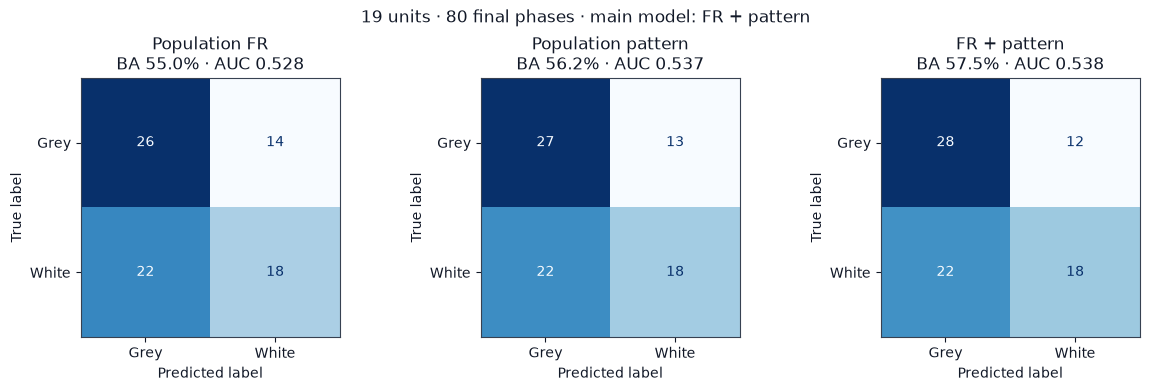

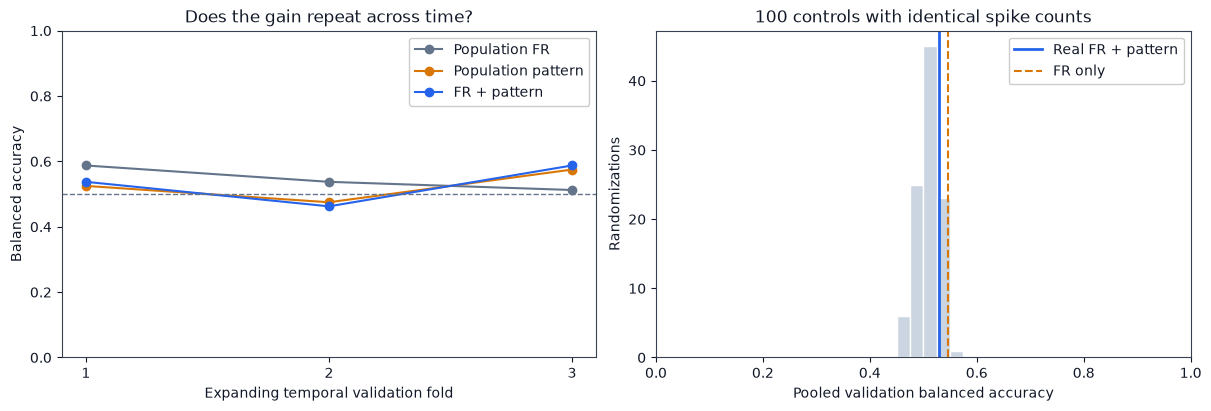

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained", facecolor="white")
for ax, name in zip(axes, inputs):
    ConfusionMatrixDisplay.from_predictions(y[test], test_predictions[name], labels=[0, 1],
        display_labels=["Grey", "White"], ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nBA {metrics.loc[name, 'test_balanced_accuracy']:.1%} · AUC {metrics.loc[name, 'test_AUC']:.3f}")
fig.suptitle(f"{len(unit_ids)} units · {len(test)} final phases · main model: {main_name}")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained", facecolor="white")
for name, color in zip(inputs, ["#64748b", "#d97706", "#2563eb"]):
    axes[0].plot([1, 2, 3], cv_results.loc[name, "balanced_accuracy"], "o-", label=name, color=color)
axes[0].axhline(0.5, linestyle="--", color="#64748b", linewidth=1)
axes[0].set(xticks=[1, 2, 3], xlabel="Expanding temporal validation fold", ylabel="Balanced accuracy",
    ylim=(0, 1), title="Does the gain repeat across time?")
axes[0].legend()
axes[1].hist(null_balanced, bins=np.linspace(0, 1, 41), color="#cbd5e1", edgecolor="white")
axes[1].axvline(cv_balanced[main_name], color="#2563eb", linewidth=2, label="Real FR + pattern")
axes[1].axvline(cv_balanced["Population FR"], color="#d97706", linestyle="--", label="FR only")
axes[1].set(xlabel="Pooled validation balanced accuracy", ylabel="Randomizations", xlim=(0, 1),
    title=f"{n_shuffles} controls with identical spike counts")
axes[1].legend()
plt.show()


All three models use the same retained phases. The default population threshold keeps
all 400 phases, unlike the earlier single-unit experiment with only 55 retained test
phases; those percentages describe different sample sets.

Look for gains over population FR that recur across temporal folds and are supported
by the count-preserving timing control. Pattern counts can encode rate-related effects,
so the raw score difference alone does not establish timing information beyond FR.

This session, including its last 80 phases, has already been inspected during development.
All results are exploratory and require fresh data for independent confirmation.
The main model remains FR + pattern regardless of which row scores highest.
After changing settings, Run All.


## 5. Further decoding: PCA, unit selection and population timing

The original 19-unit comparison above remains the reference. This extension tests
all 159 Probe A units labelled **good** by Kilosort (including genuinely silent units).
Every sample is still one complete phase; no bar position, phase index, alternating
schedule, or preceding-phase label is a predictor. All learned transformations and
unit selection use the training indices of the current fold only.

Fixed additional models: log counts + LDA; square-root counts → PCA(5) → LDA;
square-root 100 ms spike bins → PCA(10) → LDA; the 20 units with the largest
absolute training-standardized class-mean difference → LDA; and directed
neuron-neuron lag covariance from 10 ms bins → linear-kernel SVM (C=1).
Covariance uses within-phase centering and every ordered neuron pair at a one-bin lag.
It pools over phase time; unlike the exact ISI features, binning has finite time resolution.
The PCA settings and unit count are frozen after exploratory training-region screening.

The literature motivates both low-dimensional neuron × time representations
([Onken et al., 2016](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1005189))
and decoding from joint population response distributions
([Pillow et al., 2008](https://www.nature.com/articles/nature07140)).
PCA finds high variance, which need not be stimulus information. Bayesian likelihoods,
NMF, a small temporal CNN, PLS and other completed experiments are documented with
their scripts and scores in [research/results.md](research/results.md).

In [10]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

all_unit_ids = labels.index[labels.KSLabel == "good"].to_numpy()
fine_edges = np.r_[np.concatenate([np.linspace(a, b, 300, endpoint=False)
    for a, b in zip(phase_edges[:-1], phase_edges[1:])]), phase_edges[-1]]
fine_bins = np.stack([np.diff(np.searchsorted(np.sort(spike_times[clusters == u]),
    fine_edges, side="left")).reshape(len(y), 300) for u in all_unit_ids], axis=-1)
all_counts = fine_bins.sum(axis=1)
coarse_bins = fine_bins.reshape(len(y), 30, 10, len(all_unit_ids)).sum(axis=2)
rf_columns = np.array([np.flatnonzero(all_unit_ids == u).item() for u in unit_ids])
np.testing.assert_array_equal(all_counts[:, rf_columns], counts)
assert len(all_unit_ids) == 159 and np.all(all_counts.sum(axis=1) > min_population_spikes)
assert np.all(np.isfinite(fine_bins)) and np.all(fine_bins >= 0)
print(f"{len(all_unit_ids)} good units; {(all_counts[:n_train].sum(axis=0) > 0).sum()} active in training.")
print("10 ms bins preserve each phase/unit count; all models use the same 400 phases.")

def lag_covariance(B):
    z = np.sqrt(B.astype(float))
    z -= z.mean(axis=1, keepdims=True)
    with threadpool_limits(limits=1):
        return (z[:, :-1].transpose(0, 2, 1) @ z[:, 1:] / (B.shape[1] - 1)).reshape(len(B), -1)

covariance_name = "10 ms lag covariance / SVM"
selection_name = "Top 20 training units / LDA"
pca_dimensions = {"PCA 5 / counts": 5, "PCA 10 / spike bins": 10}
extra_inputs = {"All good / log counts": np.log1p(all_counts),
    "PCA 5 / counts": np.sqrt(all_counts), "PCA 10 / spike bins": np.sqrt(coarse_bins).reshape(len(y), -1),
    selection_name: np.log1p(all_counts), covariance_name: lag_covariance(fine_bins)}

159 good units; 155 active in training.
10 ms bins preserve each phase/unit count; all models use the same 400 phases.


In [11]:
def fit_extra(name, X, a, b, target=y):
    assert a.max() < b.min() and name in extra_inputs
    with threadpool_limits(limits=1):
        scaler = StandardScaler().fit(X[a])
        xa, xb = scaler.transform(X[a]), scaler.transform(X[b])
        state = {"scaler": scaler}
        if name == selection_name:
            effect = xa[target[a] == 1].mean(axis=0) - xa[target[a] == 0].mean(axis=0)
            selected = np.argsort(np.abs(effect))[-20:]
            xa, xb = xa[:, selected], xb[:, selected]
            state["selected"] = selected
        if name in pca_dimensions:
            pca = PCA(n_components=pca_dimensions[name], svd_solver="randomized", iterated_power=3, random_state=0)
            xa, xb = pca.fit_transform(xa), pca.transform(xb)
            state["pca"] = pca
        if name == covariance_name:
            norm = np.mean(np.sum(xa * xa, axis=1))
            assert norm > 0
            xa, xb = xa @ xa.T / norm, xb @ xa.T / norm
            model = SVC(kernel="precomputed", C=1, class_weight="balanced")
            state["kernel_norm"] = norm
        else:
            model = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto", priors=[0.5, 0.5])
        model.fit(xa, target[a])
        prediction, score = model.predict(xb), model.decision_function(xb)
    assert np.isfinite(score).all()
    return {**state, "model": model}, prediction, score

In [12]:
extra_cv_rows, extra_test_rows, extra_states, extra_predictions = [], [], {}, {}
for name, X in extra_inputs.items():
    for fold, (a, b) in enumerate(folds, 1):
        _, prediction, score = fit_extra(name, X, a, b)
        extra_cv_rows.append({"model": name, "fold": fold, **score_row(y[b], prediction, score)})
    state, prediction, score = fit_extra(name, X, train, test)
    extra_states[name], extra_predictions[name] = state, prediction
    extra_test_rows.append({"model": name, **score_row(y[test], prediction, score)})
extra_cv = pd.DataFrame(extra_cv_rows).set_index(["model", "fold"])
extra_test = pd.DataFrame(extra_test_rows).set_index("model")
display(extra_cv.round(4))
display(extra_test.round(4))
display(pd.Series(all_unit_ids[extra_states[selection_name]["selected"]], name="Units selected using phases 1–320"))

balanced_accuracy     AUC  pred_grey  \
model                       fold                                         
All good / log counts       1                0.5625  0.5700         43   
                            2                0.5500  0.6000         64   
                            3                0.5875  0.5962         45   
PCA 5 / counts              1                0.6000  0.5581         24   
                            2                0.5625  0.5850         49   
                            3                0.5250  0.5069         52   
PCA 10 / spike bins         1                0.5375  0.4794         35   
                            2                0.4625  0.5044         51   
                            3                0.5625  0.5300         53   
Top 20 training units / LDA 1                0.6000  0.5512         34   
                            2                0.6250  0.5856         62   
                            3                0.5750  0.5850         46   
10 ms lag covariance / SVM  1                0.5500  0.5906         20   
                            2                0.6125  0.6006         57   
                            3                0.5500  0.5350         56   

                                  pred_white             confusion  
model                       fold                                    
All good / log counts       1             37  [[24, 16], [19, 21]]  
                            2             16   [[34, 6], [30, 10]]  
                            3             35  [[26, 14], [19, 21]]  
PCA 5 / counts              1             56   [[16, 24], [8, 32]]  
                            2             31  [[27, 13], [22, 18]]  
                            3             28  [[27, 13], [25, 15]]  
PCA 10 / spike bins         1             45  [[19, 21], [16, 24]]  
                            2             29  [[24, 16], [27, 13]]  
                            3             27  [[29, 11], [24, 16]]  
Top 20 training units / LDA 1             46  [[21, 19], [13, 27]]  
                            2             18   [[36, 4], [26, 14]]  
                            3             34  [[26, 14], [20, 20]]  
10 ms lag covariance / SVM  1             60   [[12, 28], [8, 32]]  
                            2             23   [[33, 7], [24, 16]]  
                            3             24  [[30, 10], [26, 14]]

,balanced_accuracy,AUC,pred_grey,pred_white,confusion
model,,,,,
All good / log counts,0.5125,0.5187,31,49,"[[16, 24], [15, 25]]"
PCA 5 / counts,0.4500,0.4419,46,34,"[[21, 19], [25, 15]]"
PCA 10 / spike bins,0.4750,0.4638,54,26,"[[26, 14], [28, 12]]"
Top 20 training units / LDA,0.5000,0.5412,52,28,"[[26, 14], [26, 14]]"
10 ms lag covariance / SVM,0.5000,0.5619,38,42,"[[19, 21], [19, 21]]"


0     182
1     123
2     264
3     169
4     177
5     261
6      76
7      11
8     423
9     429
10    111
11    301
12     27
13    390
14    201
15    161
16    232
17    149
18    329
19    154
Name: Units selected using phases 1–320, dtype: int64

## 6. Additional controls, confined to the first 320 phases

For the covariance decoder, 100 multinomial randomizations place each unit's spikes
independently into the 300 equal-width phase bins. This is the binned equivalent of
uniform random timestamps and preserves every phase/unit count exactly.
For the unit-selection model, 100 random label swaps within adjacent white/grey pairs
repeat unit selection and fitting inside each fold. Each pair keeps one label of each class.
Both controls use seed 0. These are descriptive diagnostics for fixed models, not
p-values corrected for the broad exploratory model search or independent confirmation.

In [13]:
rng_timing, rng_labels = np.random.default_rng(0), np.random.default_rng(0)
extra_null = np.empty((n_shuffles, 2))
for repetition in range(n_shuffles):
    randomized_bins = rng_timing.multinomial(all_counts[:n_train], np.full(300, 1 / 300)).transpose(0, 2, 1)
    np.testing.assert_array_equal(randomized_bins.sum(axis=1), all_counts[:n_train])
    randomized_covariance = lag_covariance(randomized_bins)
    prediction = np.concatenate([fit_extra(covariance_name, randomized_covariance, a, b)[1] for a, b in folds])
    extra_null[repetition, 0] = balanced_accuracy_score(cv_truth, prediction)
    randomized_y = y[:n_train].reshape(-1, 2).copy()
    flip = rng_labels.integers(0, 2, len(randomized_y)).astype(bool)
    randomized_y[flip] = randomized_y[flip, ::-1]
    randomized_y = randomized_y.ravel()
    prediction = np.concatenate([fit_extra(selection_name, extra_inputs[selection_name][:n_train], a, b, randomized_y)[1] for a, b in folds])
    extra_null[repetition, 1] = balanced_accuracy_score(np.concatenate([randomized_y[b] for a, b in folds]), prediction)
    if (repetition + 1) % 20 == 0:
        print(f"Additional controls: {repetition + 1}/{n_shuffles}", flush=True)
extra_real = np.array([extra_cv.loc[name, "balanced_accuracy"].mean() for name in [covariance_name, selection_name]])
display(pd.DataFrame({"real_CV_BA": extra_real, "control_mean": extra_null.mean(axis=0),
    "control_2.5%": np.quantile(extra_null, .025, axis=0), "control_97.5%": np.quantile(extra_null, .975, axis=0),
    "fraction_control_at_least_real": (extra_null >= extra_real).mean(axis=0)},
    index=["Covariance: count-preserving timing", "Top 20 units: paired label swaps"]).round(4))

Additional controls: 20/100


Additional controls: 40/100


Additional controls: 60/100


Additional controls: 80/100


Additional controls: 100/100


,real_CV_BA,control_mean,control_2.5%,control_97.5%,fraction_control_at_least_real
Covariance: count-preserving timing,0.5708,0.5117,0.4643,0.5647,0.02
Top 20 units: paired label swaps,0.6000,0.4941,0.4353,0.5375,0.00


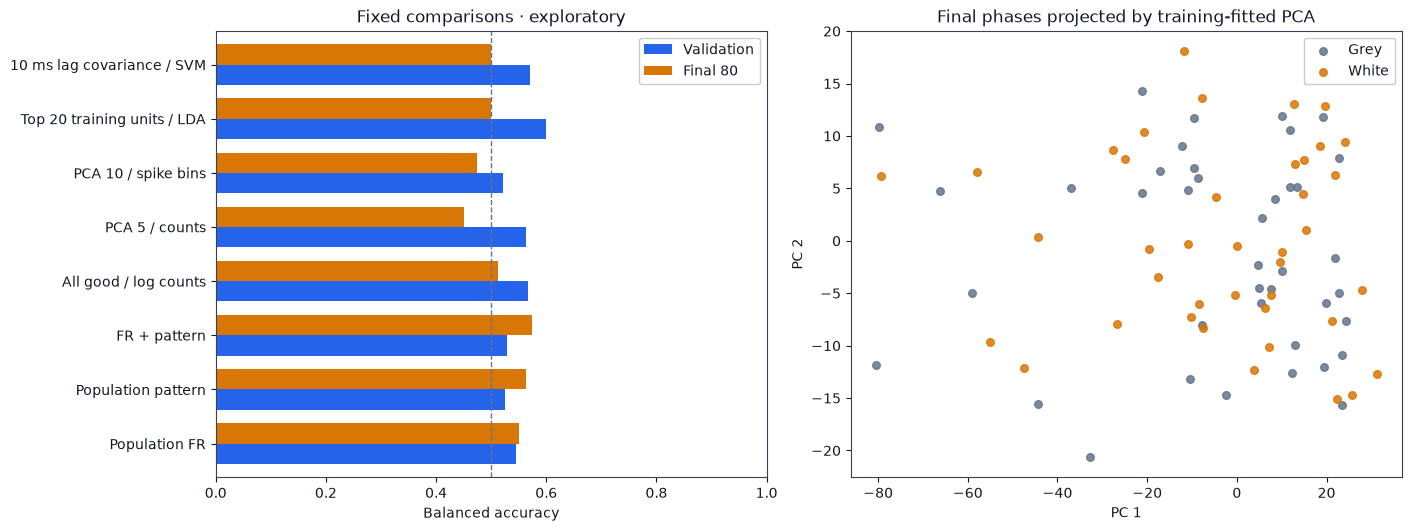

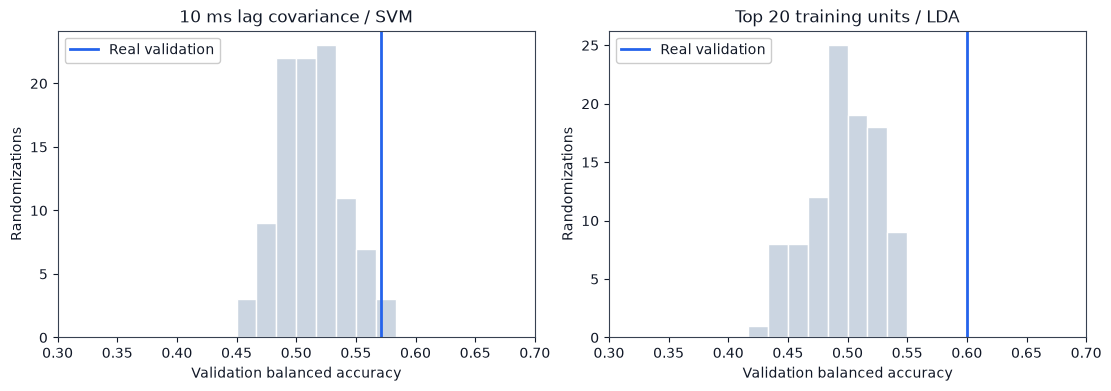

In [14]:
comparison = pd.DataFrame({"Validation": pd.concat([cv_results, extra_cv]).groupby("model", sort=False).balanced_accuracy.mean(),
    "Final 80": pd.concat([metrics.test_balanced_accuracy, extra_test.balanced_accuracy])})
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), layout="constrained", facecolor="white")
comparison.plot.barh(ax=axes[0], color=["#2563eb", "#d97706"], width=.75)
axes[0].axvline(.5, color="#64748b", linestyle="--", linewidth=1)
axes[0].set(xlim=(0, 1), xlabel="Balanced accuracy", ylabel="", title="Fixed comparisons · exploratory")
pca_state = extra_states["PCA 10 / spike bins"]
coordinates = pca_state["pca"].transform(pca_state["scaler"].transform(extra_inputs["PCA 10 / spike bins"][test]))
for c, label, color in [(0, "Grey", "#64748b"), (1, "White", "#d97706")]:
    axes[1].scatter(*coordinates[y[test] == c, :2].T, label=label, color=color, alpha=.85, s=30)
axes[1].set(xlabel="PC 1", ylabel="PC 2", title="Final phases projected by training-fitted PCA")
axes[1].legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained", facecolor="white")
for ax, name, column in zip(axes, [covariance_name, selection_name], [0, 1]):
    ax.hist(extra_null[:, column], bins=np.linspace(.3, .7, 25), color="#cbd5e1", edgecolor="white")
    ax.axvline(extra_real[column], color="#2563eb", linewidth=2, label="Real validation")
    ax.set(xlabel="Validation balanced accuracy", ylabel="Randomizations", xlim=(.3, .7), title=name)
    ax.legend()
plt.show()

These completed experiments do **not** establish a reliable white/grey decoder for
session 10. Assess the validation folds, later phases, AUC and randomized controls together;
selecting the largest percentage after screening many models overstates the evidence.
The final 80 phases have been inspected repeatedly and remain exploratory.
The PCA plot shows only two variance directions; overlap there alone does not rule out
information in other dimensions. The main reference above remains FR + pattern.

The expanded unit-selection and population-timing models are fixed comparisons, not
automatic replacements when another model fails. Loading or validation errors raise
immediately. Run All in the remote rfmapping kernel to reproduce all displayed results.

In the saved run, top-20 unit selection reaches 60% validation BA and 50% final BA;
PCA on counts reaches 45% final BA, PCA on spike bins 47.5%, and lag covariance 50%.
Labels currently assume MAT trials are in actual playback order. The Randomize=1
metadata still needs provenance confirmation; event-clock checks do not establish
luminance identity. See research/results.md for the completed data audit.
